In [29]:
from netCDF4 import *
import matplotlib.pyplot as plt
import matplotlib.lines as ln
import json

from matplotlib import rc

font = {"family": "serif", "weight": "normal", "size": 13}
rc("font", **font)
rc("text", usetex=True)

In [30]:
def load_tracks(file) :
    tracks = []
    with open("vortexes\\Tracks_"+file+".json", "r") as f:
        tracks = json.load(f)
    return tracks

In [31]:
def plot_tracks(trange,tracks,color,track_all = False) :
    ax = plt.gca()

    track_plot =[]

    #loop the tracks
    for track in tracks:

        #select only the tracks starting at t = 0 
        if track_all or track[1][0] != None :
            track_plot.append([[],[]])

            #loop the time
            for t in trange :

                #select only when the position is not the default value
                if track[t][0] != None and track[t][1] != None :

                    #transpose the tracks to a plottable array for each component
                    track_plot[-1][0].append(track[t][1])
                    track_plot[-1][1].append(track[t][0])
    
    #plot the tracks
    for track in track_plot :
        if track[0] != [] :
            ax.scatter(track[0][0], track[1][0],color = color, s = 2 )
            ax.scatter(track[0], track[1],color = color, s = 1 )
            ax.plot(track[0], track[1],color = color)


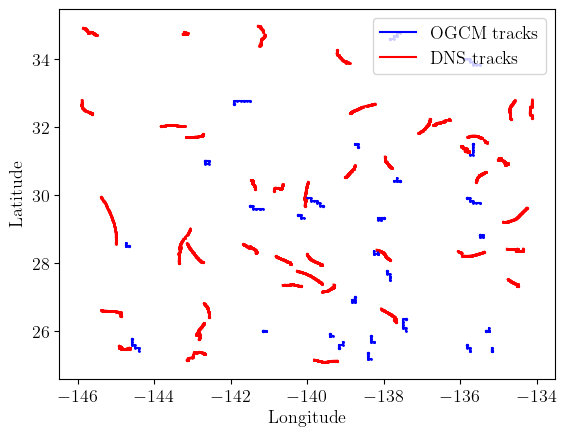

In [32]:
#Time range to plot
trange = range(10)

#plot the OGCM json vortex file 
tracks = load_tracks("GLORYS_2022_cropped")
plot_tracks(trange,tracks,"blue")


trange = range(100)
#plot the DNS json vortex file 
tracks = load_tracks("dekad_0")
plot_tracks(trange,tracks,"red")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

#custom legend
blue_line = ln.Line2D([], [], color='blue', label='OGCM tracks')
red_line = ln.Line2D([], [], color='red', label='DNS tracks')
plt.legend(handles=[blue_line,red_line])
